Final project python, Chairetaki Antonia, April 2025, Master in Bioinformatic, second semester, Heraklion, Crete
Codon usage bias correlation to gene expression levels in B-cells in humans

At first, we download and extract all the request file:
The gene expression levels in B-cells in humans.
The human genome in fasta format.
The coding Sequences from the human genome.

In [93]:
import os
import requests
import tarfile
import gzip
import shutil

def download_files():
    request_file_1 = "SRX220838_gene.txt.gz"
    request_file_2 = "GCF_000001405.40_GRCh38.p14_genomic.fna.gz"
    request_file_3 = "GCF_000001405.40_GRCh38.p14_cds_from_genomic.fna.gz"
    extracted_file_1 = "SRX220838_gene"
    extracted_file_2 = "GCF_000001405.40_GRCh38.p14_genomic"
    extracted_file_3 = "GCF_000001405.40_GRCh38.p14_cds_from_genomic"
    file_url_1 = "https://ngdc.cncb.ac.cn/mtd/download/human/SRX220838_gene.txt.gz"
    file_url_2 = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/405/GCF_000001405.40_GRCh38.p14/GCF_000001405.40_GRCh38.p14_genomic.fna.gz"
    file_url_3 = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/405/GCF_000001405.40_GRCh38.p14/GCF_000001405.40_GRCh38.p14_cds_from_genomic.fna.gz"

    #Download the expession data for B-cells in humans    
    if not os.path.exists(request_file_1):
        print("Downloading B cell, gene expression...")
        response = requests.get(file_url_1)
        with open(request_file_1, 'wb') as file:
            file.write(response.content)
        print("Download of expression data complete succesfully")
    else:
        print("Gene expression levels for B-cells already exist, skipping download")
    
    #Extract the expression data
    if not os.path.exists(extracted_file_1):
        print("Extracting expression data...")
        with gzip.open(request_file_1, "rb") as f_in:
            with open(extracted_file_1, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print("Extraction of expression data complete successfully")

    #Download the human genome
    if not os.path.exists(request_file_2):
        print("Downloading human genome...")
        response = requests.get(file_url_2)
        with open(request_file_2, 'wb') as file:
            file.write(response.content)
        print("Download of human genome complete succesfully")
    else:
        print("Human genome already exist, skipping downloading")
    
    #Extract the human genome
    #keeping the .fna in the output file, to use the file for tRNAscan
    if request_file_2.endswith(".gz"):
        extracted_file_2 = request_file_2[:-3]  
    else:
        extracted_file_2 = request_file_2
    
    if not os.path.exists(extracted_file_2):
        print("Extracting human genome...")
        with gzip.open(request_file_2, "rb") as f_in:
            with open(extracted_file_2, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print("Extraction of human genome complete successfully")
    
    #Download the coding sequences
    if not os.path.exists(request_file_3):
        print("Downloading cds from human genome...")
        response = requests.get(file_url_3)
        with open(request_file_3, 'wb') as file:
            file.write(response.content)
        print("Download of coding sequences complete succesfully")
    else:
        print("Cds for human genome already exist, skipping downloading")  
    
    #Extract the coding sequences
    if not os.path.exists(extracted_file_3):
        print("Extracting coding sequences...")
        with gzip.open(request_file_3, "rb") as f_in:
            with open(extracted_file_3, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print("Extraction of coding sequences complete successfully")

download_files()

Gene expression levels for B-cells already exist, skipping download
Human genome already exist, skipping downloading
Cds for human genome already exist, skipping downloading


Download and install necessary tool
tRNAscan-SE-2.0.12 and its dependencies. Attention that tRNAscan, also need perl to be executed, so if its not install in your device, you should first install to proceed.

In [94]:
import tarfile
import subprocess
import sys

def download_tools():
    request_tool_1 = "infernal-1.1.5-linux-intel-gcc.tar.gz"
    request_tool_2 = "tRNAscan-SE-2.0.12.tar.gz" 
    extracted_tool_1 = "infernal-1.1.5-linux-intel-gcc"
    extracted_tool_2 = "RNAscan-SE-2.0.12"
    tools_url_1 = "http://eddylab.org/infernal/infernal-1.1.5-linux-intel-gcc.tar.gz"
    tools_url_2 = "https://github.com/UCSC-LoweLab/tRNAscan-SE/archive/refs/tags/v2.0.12.tar.gz"
    
    #Download infernal
    if not os.path.exists(request_tool_1):
        print("Downloading infernal...")
        response = requests.get(tools_url_1, verify=False)
        if response.status_code == 200:
            with open("infernal-1.1.5-linux-intel-gcc.tar.gz", 'wb') as file_1:
                file_1.write(response.content)
                print("Download complete succesfully")
    else:
        print("Infernal already exist, skipping download")

    #Extract infernal
    if not os.path.exists(extracted_tool_1):
        print("Extracting infernal...")
        with tarfile.open(request_tool_1, "r:gz") as tar:
            tar.extractall(path=extracted_tool_1)
        print("Extraction complete succesfully\n\
Please proceed to installation of infernal and rerun the script\n\
Installation:\n./configure\nmake")
        exit
    
    #Download tRNAscan
    if not os.path.exists(request_tool_2):
        print("Downloading tRNAscan-SE 2.0...")
        response = requests.get(tools_url_2)
        if response.status_code == 200:
            with open("tRNAscan-SE-2.0.12.tar.gz", 'wb') as file_2:
                file_2.write(response.content)
                print("Download complete succesfully")
    else:
        print("tRNAscan-SE-2.0 already exist, skipping download")
    
    #Extract tRNAscan
    if not os.path.exists(extracted_tool_2):
        print("Extracting tRNAscan...")
        with tarfile.open(request_tool_2, "r:gz") as tar:
            tar.extractall(path=extracted_tool_2)
        print("Extraction complete succesfully\n\
Please proceed to installation of RNAscan-SE-2.0.12 and rerun the script\n\
Installation:\n./configure\nmake")
        exit

download_tools()

Infernal already exist, skipping download
tRNAscan-SE-2.0 already exist, skipping download


The following function is designed to run tRNAscan-SE to find the tRNA genes in the human genome. However, if you experience any troubleshooting with the next function, you can try running the following command directly to your terminal:
tRNAscan-SE  tRNAscan-SE -o human.tRNAscan.out GCF_000001405.40_GRCh38.p14_genomic.fna

In [95]:
import subprocess
import os

def scan_for_tRNA():
    
    if os.path.exists("human.tRNAscan.out"):
        print(f"The output file human.tRNAscan.out already exists. Aborting the scan.")
        return
    command = ["./RNAscan-SE-2.0.12/tRNAscan-SE-2.0.12/tRNAscan-SE", "-o", "human.tRNAscan.out", "GCF_000001405.40_GRCh38.p14_genomic.fna"]
    try:
       print("Runing tRNAscan...")
       subprocess.run(command, check=True, capture_output=True, text=True)
       print("tRNAscan run succesfully")
    except subprocess.CalledProcessError as e:
       print(f"An error occurred while running tRNAscan-SE: {e}")
scan_for_tRNA()
    

The output file human.tRNAscan.out already exists. Aborting the scan.


Parcing the GCF_000001405.40_GRCh38.p14_cds_from_genomic file in a dictionary, so that the key of the dictionary to be the gene name and the value to be the longest sequence of the gene that is available in the file (the longest isoform) 

In [96]:
import re

def parcing_cd_genome():

    with open("GCF_000001405.40_GRCh38.p14_cds_from_genomic", 'r') as my_file:
        gene_cds_dict = {}
        gene_key = None
        sequence = ''
        for line in my_file:
            line = line.strip()
            if line.startswith(">"):
                if "[gene=" in line:
                    start_index = line.find("[gene=") + len("[gene=")
                    end_index = line.find("]", start_index)
                    gene_key = line[start_index:end_index]
                    if gene_key and sequence:
                        if gene_key not in gene_cds_dict:
                            gene_cds_dict[gene_key] = sequence
                        else:
                            if len(sequence) > len(gene_cds_dict[gene_key]):
                                gene_cds_dict[gene_key] = sequence
                sequence = '' 
            else:
                sequence += line.replace("\n",'')           
        if gene_key != None and sequence != None:
            if gene_key not in gene_cds_dict:
                gene_cds_dict[gene_key] = sequence
            else:
                if len(sequence) > len(gene_cds_dict[gene_key]):
                    gene_cds_dict[gene_key] = sequence
   
    return gene_cds_dict
gene_cds_dict = parcing_cd_genome()

#Checking if my dictionary is structured correctly
first_4_keys = list(gene_cds_dict.keys())[:4]
first_4_values = list(gene_cds_dict.values())[:4]
last_4_keys = list(gene_cds_dict.keys())[-4:]
last_4_values = list(gene_cds_dict.values())[-4:]
print("First 4 key-value pairs:")
for key, value in zip(first_4_keys, first_4_values):
    print(f"Gene: {key}, Sequence: {value}")
print("\nLast 4 key-value pairs:")
for key, value in zip(last_4_keys, last_4_values):
    print(f"Gene: {key}, Sequence: {value}")

First 4 key-value pairs:
Gene: LOC112268260, Sequence: ATGAAGAAGGTAACTGCAGAGGCTATTTCCTGGAATGAATCAACGAGTGAAACGAATAACTCTATGGTGACTGAATTCATTTTTCTGGGTCTCTCTGATTCTCAGGAACTCCAGACCTTCCTATTTATGTTGTTTTTTGTATTCTATGGAGGAATCGTGTTTGGAAACCTTCTTATTGTCATAACAGTGGTATCTGACTCCCACCTTCACTCTCCCATGTACTTCCTGCTAGCCAACCTCTCACTCATTGATCTGTCTCTGTCTTCAGTCACAGCCCCCAAGATGATTACTGACTTTTTCAGCCAGCGCAAAGTCATCTCTTTCAAGGGCTGCCTTGTTCAGATATTTCTCCTTCACTTCTTTGGTGGGAGTGAGATGGTGATCCTCATAGCCATGGGCTTTGACAGATATATAGCAATATGCAAGCCCCTACACTACACTACAATTATGTGTGGCAACGCATGTGTCGGCATTATGGCTGTCACATGGGGAATTGGCTTTCTCCATTCGGTGAGCCAGTTGGCGTTTGCCGTGCACTTACTCTTCTGTGGTCCCAATGAGGTCGATAGTTTTTATTGTGACCTTCCTAGGGTAATCAAACTTGCCTGTACAGATACCTACAGGCTAGATATTATGGTCATTGCTAACAGTGGTGTGCTCACTGTGTGTTCTTTTGTTCTTCTAATCATCTCATACACTATCATCCTAATGACCATCCAGCATCGCCCTTTAGATAAGTCGTCCAAAGCTCTGTCCACTTTGACTGCTCACATTACAGTAGTTCTTTTGTTCTTTGGACCATGTGTCTTTATTTATGCCTGGCCATTCCCCATCAAGTCATTAGATAAATTCCTTGCTGTATTTTATTCTGTGATCACCCCTCTCTTGAACCCAATTATATACACACTGAGGAACAAAGACATGAAGACGGCAATAAGACAGCTG

Parcing the SRX220838_gene file which contain the expression data in a dictionary, so that the key of the dictionary to be the gene name and the value to be the expression level of the gene isoform with the higher expression level that is available in the file.

In [97]:
def parce_expression_data():

    gene_expression_dict = {}

    with open("SRX220838_gene", 'r') as file:
        next(file)
        for line in file:
            columns = line.strip().split('\t')
            gene_name = columns[1]
            expression_level = columns[6]
            if gene_name in gene_expression_dict:
                if expression_level > gene_expression_dict[gene_name]:
                   gene_expression_dict[gene_name] = expression_level
            else:
                gene_expression_dict[gene_name] = expression_level

    return gene_expression_dict

gene_expression_dict = parce_expression_data()

print(gene_expression_dict)

{'CBY1': '102.205', 'C2orf68': '23.3304', 'ZFP82': '4.91007', 'ITPR1': '6.01209', 'MED23': '2.35263', 'MRPL53': '52.518', 'GPD2': '54.9957', 'IFT80': '2.99363', 'WDR66': '3.64403', 'CNOT6': '33.7128', 'TTC5': '7.13008', 'STK11': '19.2759', 'ZNF714': '9.65435', 'TBC1D12': '10.6791', 'KDM2B': '7.07742', 'SLC38A7': '4.61', 'FAM86A': '5.72671', 'IKZF1': '16.0227', 'DENND1C': '22.8543', 'RRAGC': '14.6391', 'CD46': '112.714', 'RAD9A': '19.9377', 'FRA10AC1': '4.10506', 'PLOD1': '16.7571', 'IER5': '5.53933', 'GNL1': '1.53707', 'GSTK1': '159.257', 'AP1G1': '24.9879', 'UTP11L': '6.41553', 'ICMT': '25.6845', 'UFD1L': '38.804', 'HS1BP3': '5.38567', 'MIR26A2': '29941.7', 'EAF1': '30.4095', 'NSFL1C': '7.46952', 'ANO10': '6.04234', 'RBM15': '15.2028', 'NCAPH2': '7.53808', 'TMEM200A': '26.3271', 'TINCR': '3.39441', 'LRP12': '30.4605', 'YIPF3': '34.5278', 'HINT3': '3.73011', 'ZNF91': '18.2483', 'GPR75': '18.1735', 'HMGN4': '26.855', 'ZNF670': '5.93268', 'PRUNE': '106.771', 'PPAPDC2': '4.26778', 'MRPS24

Reading the tRNAscan output, removing all the pseudo genes and all the genes with Inferred secondary structure confidence score (Inf score), less than 30, as they are not strongly supported as valuable according to the scan. After, I save the rest anticodons, replace them with codons and count how many times each codon appears in the scan, in a dictionary.

In [98]:
import re
from collections import defaultdict

#change anticodons to codons
def anticodon_to_codon(anticodon):
    reversed_seq = anticodon[::-1]
    complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
    return ''.join(complement.get(base,base) for base in reversed_seq)

def parce_trnascan_output():
     
    codon_usage_dict= defaultdict(int) #create with all the values to be 0, at first

    with open("human.tRNAscan.out", "r") as my_file:
        for line in my_file:
            line = line.strip()
            if line == '' or line.startswith('Sequence') or line.startswith('--------'):
                continue   #skip the first lines of the file
            column = re.split(r'\s+', line)  #split the columns with tap, since the file structure is not ideal
            try:
                score = float(column[8])
            except (ValueError, IndexError):
                continue
            if 'pseudo' in column: #ignore pseudo genes
                continue
            if score > 30: #keep only genes with relative high score
                anticodon = column[5]
                codon = anticodon_to_codon(anticodon) #call the other function to change anticodons to codons
                codon_usage_dict[codon] += 1 #count the codons

    return codon_usage_dict

parce_trnascan_output()

defaultdict(int,
            {'GGG': 17,
             'GAA': 16,
             'AAC': 50,
             'AGA': 6,
             'CAG': 25,
             'GTG': 20,
             'GAG': 15,
             'GGA': 9,
             'CAC': 10,
             'AAG': 18,
             'AAT': 2,
             'ATG': 34,
             'CTG': 10,
             'GGC': 15,
             'CCG': 4,
             'AAA': 28,
             'ACA': 6,
             'CCA': 8,
             'TTG': 17,
             'GTT': 17,
             'CCT': 11,
             'GAC': 17,
             'GCT': 83,
             'TGC': 33,
             'TAC': 18,
             'CTT': 22,
             'ATA': 6,
             'GTA': 6,
             'GCG': 11,
             'TAT': 1,
             'CGT': 8,
             'GCA': 38,
             'CGA': 7,
             'TCT': 11,
             'ATT': 19,
             'AGC': 9,
             'ACT': 13,
             'TCG': 4,
             'TCA': 4,
             'ACG': 7,
             'CAA': 7,
             'T

I am using the tRNAscan output file, to give a score for each gene, corresponding to the availability of tRNAs for each codon in the sequence. Higher score means more available tRNAs for the codons for this specific gene, so this gene has more optimal codons compare to a gene with less score for the same organism 

In [99]:
codon_usage_dict = parce_trnascan_output()

def ratio_of_optimal_codons(gene_cds_dict, codon_usage_dict):
    
    gene_score_dict = {}
    stop_codons = {'TAA', 'TAG', 'TGA'}

    #create a list with codons for each gene
    for gene, sequence in gene_cds_dict.items():
        codon_list = [sequence[i:i+3] for i in range(0, len(sequence) - len(sequence)%3, 3)]
        total_codons = len(codon_list)
        
        if total_codons == 0:
            gene_score_dict[gene] = 0
            continue
        score = 0 

        for codon in codon_list:
            if codon in stop_codons: #break if you meet a stop codon
                break 
            else:
                score += codon_usage_dict.get(codon, 0) #add the codon usage from tRNAscan output for each codon to the score
                average_score = score/total_codons

        #make a dict with the final score with 2 decimal for each gene
        gene_score_dict[gene] = round(average_score, 2)

    return gene_score_dict

ratio_of_optimal_codons(gene_cds_dict, codon_usage_dict)

{'LOC112268260': 14.23,
 'OR4F29': 12.29,
 'LOC105378947': 13.3,
 'OR4F16': 11.74,
 'SAMD11': 12.82,
 'NOC2L': 12.89,
 'KLHL17': 15.37,
 'PLEKHN1': 12.43,
 'PERM1': 14.12,
 'HES4': 14.12,
 'ISG15': 12.18,
 'AGRN': 13.68,
 'RNF223': 13.56,
 'C1orf159': 13.41,
 'TTLL10': 13.29,
 'TNFRSF18': 13.91,
 'TNFRSF4': 11.38,
 'SDF4': 15.21,
 'B3GALT6': 14.26,
 'C1QTNF12': 13.63,
 'UBE2J2': 13.32,
 'SCNN1D': 13.8,
 'ACAP3': 14.59,
 'PUSL1': 13.96,
 'INTS11': 15.22,
 'CPTP': 15.5,
 'TAS1R3': 14.98,
 'DVL1': 15.19,
 'MXRA8': 13.21,
 'AURKAIP1': 13.58,
 'CCNL2': 13.62,
 'MRPL20': 14.34,
 'ANKRD65': 12.54,
 'TMEM88B': 12.32,
 'LOC107985729': 11.02,
 'VWA1': 12.69,
 'ATAD3C': 13.22,
 'ATAD3B': 13.84,
 'ATAD3A': 13.8,
 'TMEM240': 13.85,
 'SSU72': 14.7,
 'FNDC10': 14.93,
 'MIB2': 13.67,
 'MMP23B': 14.59,
 'CDK11B': 14.73,
 'SLC35E2B': 14.32,
 'CDK11A': 14.6,
 'NADK': 14.56,
 'GNB1': 15.2,
 'CALML6': 16.14,
 'TMEM52': 12.49,
 'CFAP74': 12.4,
 'GABRD': 14.25,
 'PRKCZ': 13.83,
 'FAAP20': 14.12,
 'SKI': 13.3

I am using matplot and numpy to make a pearson correlation analysis of my data. More specificly, I check if the gene expression level and the optimal codon range for each gene are related in a linear way. The following function is not going to work if you don't have numpy, matplot and scipy, so you might want to install these programs via conda and then try to run the next script.

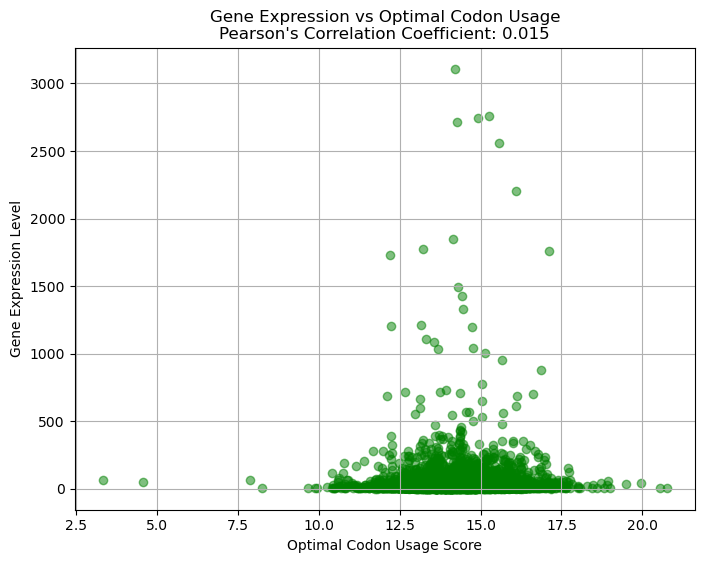

No statistically significant correlation(r = 0.015, p = 1.95e-01).


In [100]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr 

def pearson_correlation():

    gene_score_dict = ratio_of_optimal_codons(gene_cds_dict, codon_usage_dict)
    gene_expression_dict = parce_expression_data()

    #checking for common keys
    common_keys = set(gene_score_dict.keys()).intersection(gene_expression_dict.keys())

    gene_optimal_codons = [float(gene_score_dict[key]) for key in common_keys]
    gene_expression_level = [float(gene_expression_dict[key]) for key in common_keys]
   
    correlation_coefficient, p_value = pearsonr(gene_optimal_codons, gene_expression_level)

    plt.figure(figsize=(8, 6))
    plt.scatter(gene_optimal_codons, gene_expression_level, color='green', alpha=0.5)
    plt.title(f"Gene Expression vs Optimal Codon Usage\nPearson's Correlation Coefficient: {correlation_coefficient:.3f}")
    plt.xlabel("Optimal Codon Usage Score")
    plt.ylabel("Gene Expression Level")
    plt.grid(True)
    plt.show()

    if p_value < 0.05:
        print(f"Significant correlation (r = {correlation_coefficient:.3f}, p = {p_value:.2e})")
        if correlation_coefficient > 0:
            print("→ Positive correlation.")
        else:
            print("→ Negative correlation.")
    else:
        print(f"No statistically significant correlation(r = {correlation_coefficient:.3f}, p = {p_value:.2e}).")

pearson_correlation()

In conclusion, our analysis shows no significant correlation between gene expression levels and optimal codon usage among genes in human B cells. Below, I present some thoughts on possible explanations that might account for these observations.

First, there were limitations in our initial dataset. We didn’t have expression data for all genes — only a subset — so we were forced to restrict our analysis to that portion (approximately 2/5 of all human genes).

From the plot, we can also observe that there is not much variation in optimal codon usage, as most genes have similar average scores. Similarly, gene expression levels also show limited variation, with most genes maintaining relatively low expression rates.

Finally, we must consider the influence of the chosen cell type. B cells are known to have unique characteristics in terms of gene expression. When activated, they are required to express very high levels of specific antibody genes, and these vary depending on the antigen they encounter. As a result, B cells need to be capable of overexpressing a wide variety of genes on demand, without maintaining a fixed preference for certain genes.

Moreover, genes related to the immune system, such as those encoding antibodies, are not under strong evolutionary pressure to remain conserved. On the contrary, they tend to accumulate new mutations to allow recognition of a broader range of antigens. With this in mind, it's unlikely that these genes would be evolutionarily adapted to match the organism’s codon bias — a conclusion that aligns with our findings.